# SemEval-2022 Task 8 — Cross-lingual News NLI
**Full Pipeline: Load → Clean → EDA → Fine-tune 4 Models → Evaluate**

Models: mDeBERTa-v3 · XLM-RoBERTa · InfoXLM · mBERT

## 0. Setup — Install Packages

In [1]:
!pip install -q transformers datasets accelerate scikit-learn seaborn

## 1. Imports & Device

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.metrics import (
    f1_score, accuracy_score, cohen_kappa_score, classification_report
)
from sklearn.model_selection import train_test_split
from datasets import load_dataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

LABEL2ID = {'ENTAIL': 0, 'NEUTRAL': 1, 'CONTRADICT': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Load Dataset


In [3]:
from google.colab import files

uploaded = files.upload()  # upload final_dataset_clean.csv when prompted

df = pd.read_csv('final_dataset_clean.csv')

print(f'Total pairs: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nLanguage pairs:\n{df["lang_pair"].value_counts()}')
print(f'\nLabel distribution:\n{df["label"].value_counts()}')
print(f'\nScore scale: 1=very similar (ENTAIL), 4=very different (CONTRADICT)')

Saving final_dataset_clean.csv to final_dataset_clean.csv
Total pairs: 3608
Columns: ['pair_id', 'annotator_id', 'lang_pair', 'lang1', 'lang2', 'text1', 'text2', 'text_source', 'link1', 'link2', 'content_similarity', 'GEO', 'ENT', 'TIME', 'NAR', 'OVERALL', 'STYLE', 'TONE', 'FRAME', 'source_file', 'len_a', 'len_b', 'Overall', 'label', 'label_id', 'len1', 'len2']

Language pairs:
lang_pair
de-en    1555
es-en     740
es-it     472
zh-en     398
de-fr     171
fr-en      98
pl-en      88
de-pl      46
fr-pl      40
Name: count, dtype: int64

Label distribution:
label
NEUTRAL       1524
CONTRADICT    1422
ENTAIL         662
Name: count, dtype: int64

Score scale: 1=very similar (ENTAIL), 4=very different (CONTRADICT)


### 3. Cleaning the dataset


In [4]:
MIN_WORDS = 3    # titles are short (~9 words avg)
MAX_WORDS = 390  # ~512 tokens after subword tokenization

df['text1'] = df['text1'].fillna('').astype(str)
df['text2'] = df['text2'].fillna('').astype(str)
df['len1']  = df['text1'].apply(lambda x: len(x.split()))
df['len2']  = df['text2'].apply(lambda x: len(x.split()))

before = len(df)
df = df[(df['len1'] >= MIN_WORDS) & (df['len2'] >= MIN_WORDS)].copy()
print(f'Dropped {before - len(df)} too-short pairs → {len(df)} remaining')

def truncate(text, n=MAX_WORDS):
    return ' '.join(str(text).split()[:n])

df['text1'] = df['text1'].apply(truncate)
df['text2'] = df['text2'].apply(truncate)

# re-derive labels from corrected Overall scores
def score_to_label(s):
    if s <= 1.5:  return 'ENTAIL'
    if s <= 2.5:  return 'NEUTRAL'
    return 'CONTRADICT'

df['label']    = df['Overall'].apply(score_to_label)
df['label_id'] = df['label'].map({'ENTAIL':0,'NEUTRAL':1,'CONTRADICT':2})

print(f'\nLabel distribution:\n{df["label"].value_counts()}')
print(f'\nScore scale: 1=very similar, 4=very different')

Dropped 427 too-short pairs → 3181 remaining

Label distribution:
label
NEUTRAL       1390
CONTRADICT    1199
ENTAIL         592
Name: count, dtype: int64

Score scale: 1=very similar, 4=very different


## 4. Deep ED 4.1 Basic Stats & Data Quality

In [5]:
print(f"Shape: {df.shape}")
print(f"\nMissing values (key columns only):")
key_cols = ['text1','text2','Overall','lang_pair','label','content_similarity','GEO','ENT','TIME','NAR','STYLE','TONE']
print(df[key_cols].isnull().sum())
print(f"\nAll text sources: {df['text_source'].value_counts().to_dict()}")
print(f"\nScore summary:")
score_cols = ['Overall','GEO','ENT','TIME','NAR','STYLE','TONE']
print(df[score_cols].describe().round(3))

Shape: (3181, 27)

Missing values (key columns only):
text1                 0
text2                 0
Overall               0
lang_pair             0
label                 0
content_similarity    0
GEO                   0
ENT                   0
TIME                  0
NAR                   0
STYLE                 0
TONE                  0
dtype: int64

All text sources: {'title_only': 3181}

Score summary:
        Overall       GEO       ENT      TIME       NAR     STYLE      TONE
count  3181.000  3181.000  3181.000  3181.000  3181.000  3181.000  3181.000
mean      2.566     3.069     2.613     2.868     2.366     3.066     3.081
std       1.006     0.951     0.991     1.054     1.022     0.869     0.809
min       1.000     1.000     1.000     1.000     1.000     1.000     1.000
25%       2.000     2.500     2.000     2.500     1.000     2.500     2.500
50%       2.500     3.000     2.500     2.500     2.500     3.000     3.000
75%       3.000     4.000     3.000     4.000     3.000  

### 4.2 Overall Score Distribution & NLI Label Mapping

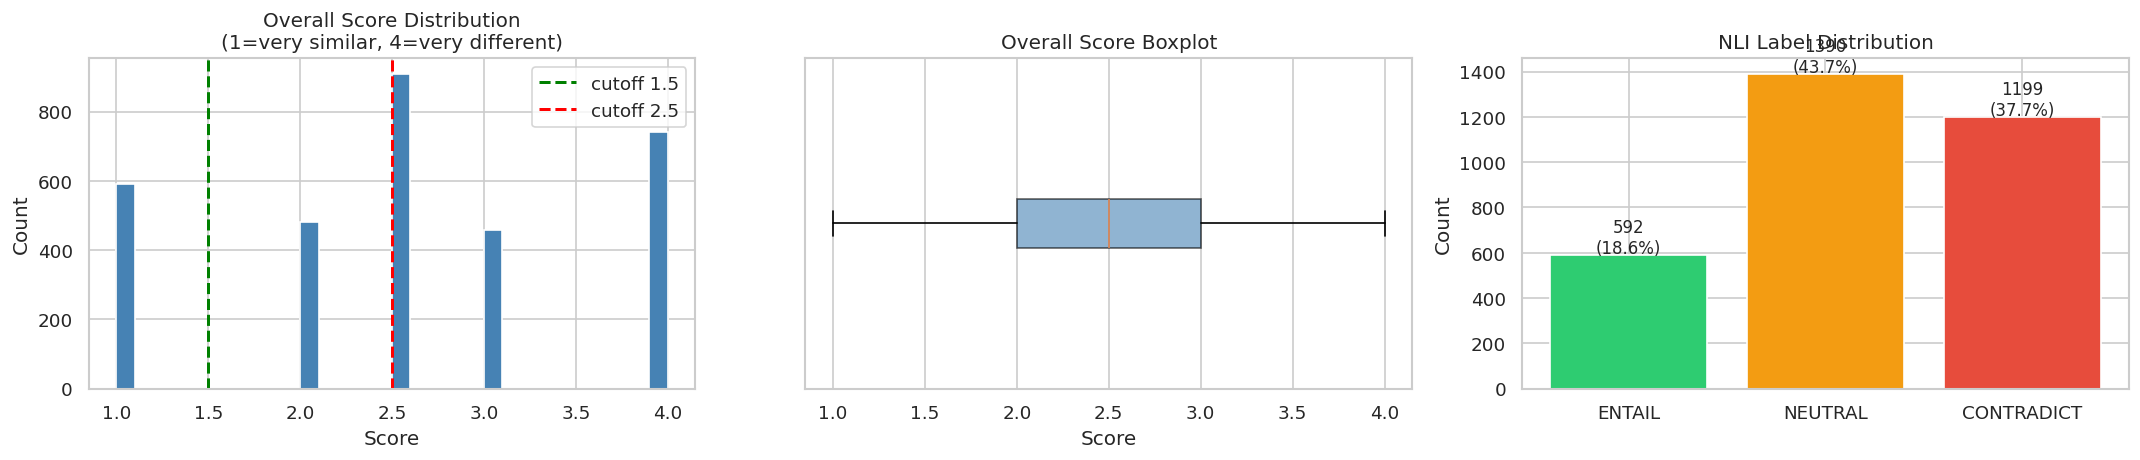


Value counts:
Overall
1.0    592
2.0    481
2.5    909
3.0    459
4.0    740
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# histogram with cutoffs
axes[0].hist(df['Overall'], bins=30, color='steelblue', edgecolor='white')
for x, c, lbl in zip([1.5, 2.5], ['green','red'], ['ENTAIL/NEUTRAL','NEUTRAL/CONTRADICT']):
    axes[0].axvline(x, color=c, linestyle='--', linewidth=1.8, label=f'cutoff {x}')
axes[0].set_title('Overall Score Distribution\n(1=very similar, 4=very different)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# boxplot
axes[1].boxplot(df['Overall'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Overall Score Boxplot')
axes[1].set_xlabel('Score')
axes[1].set_yticks([])

# label bar chart
counts = df['label'].value_counts().reindex(['ENTAIL','NEUTRAL','CONTRADICT'])
bars = axes[2].bar(counts.index, counts.values,
                   color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[2].set_title('NLI Label Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(f"\nValue counts:\n{df['Overall'].value_counts().sort_index()}")

### 4.3 Language Pair Breakdown

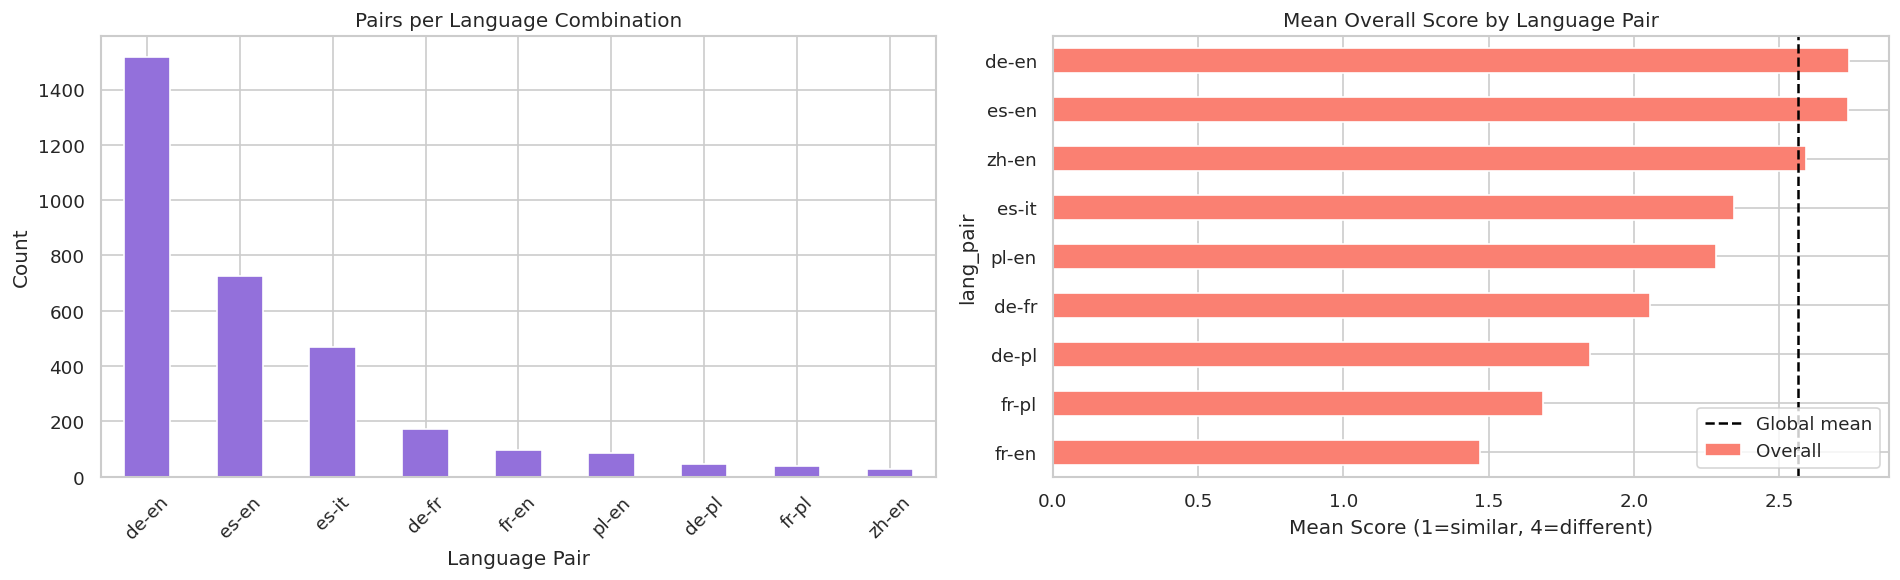

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['lang_pair'].value_counts().plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Pairs per Language Combination')
axes[0].set_xlabel('Language Pair')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

lang_score = df.groupby('lang_pair')['Overall'].mean().sort_values()
lang_score.plot(kind='barh', ax=axes[1], color='salmon', edgecolor='white')
axes[1].axvline(df['Overall'].mean(), color='black', linestyle='--', label='Global mean')
axes[1].set_title('Mean Overall Score by Language Pair')
axes[1].set_xlabel('Mean Score (1=similar, 4=different)')
axes[1].legend()
plt.tight_layout()
plt.show()

### 4.4 Sub-dimension Scores, Content Similarity & Correlation

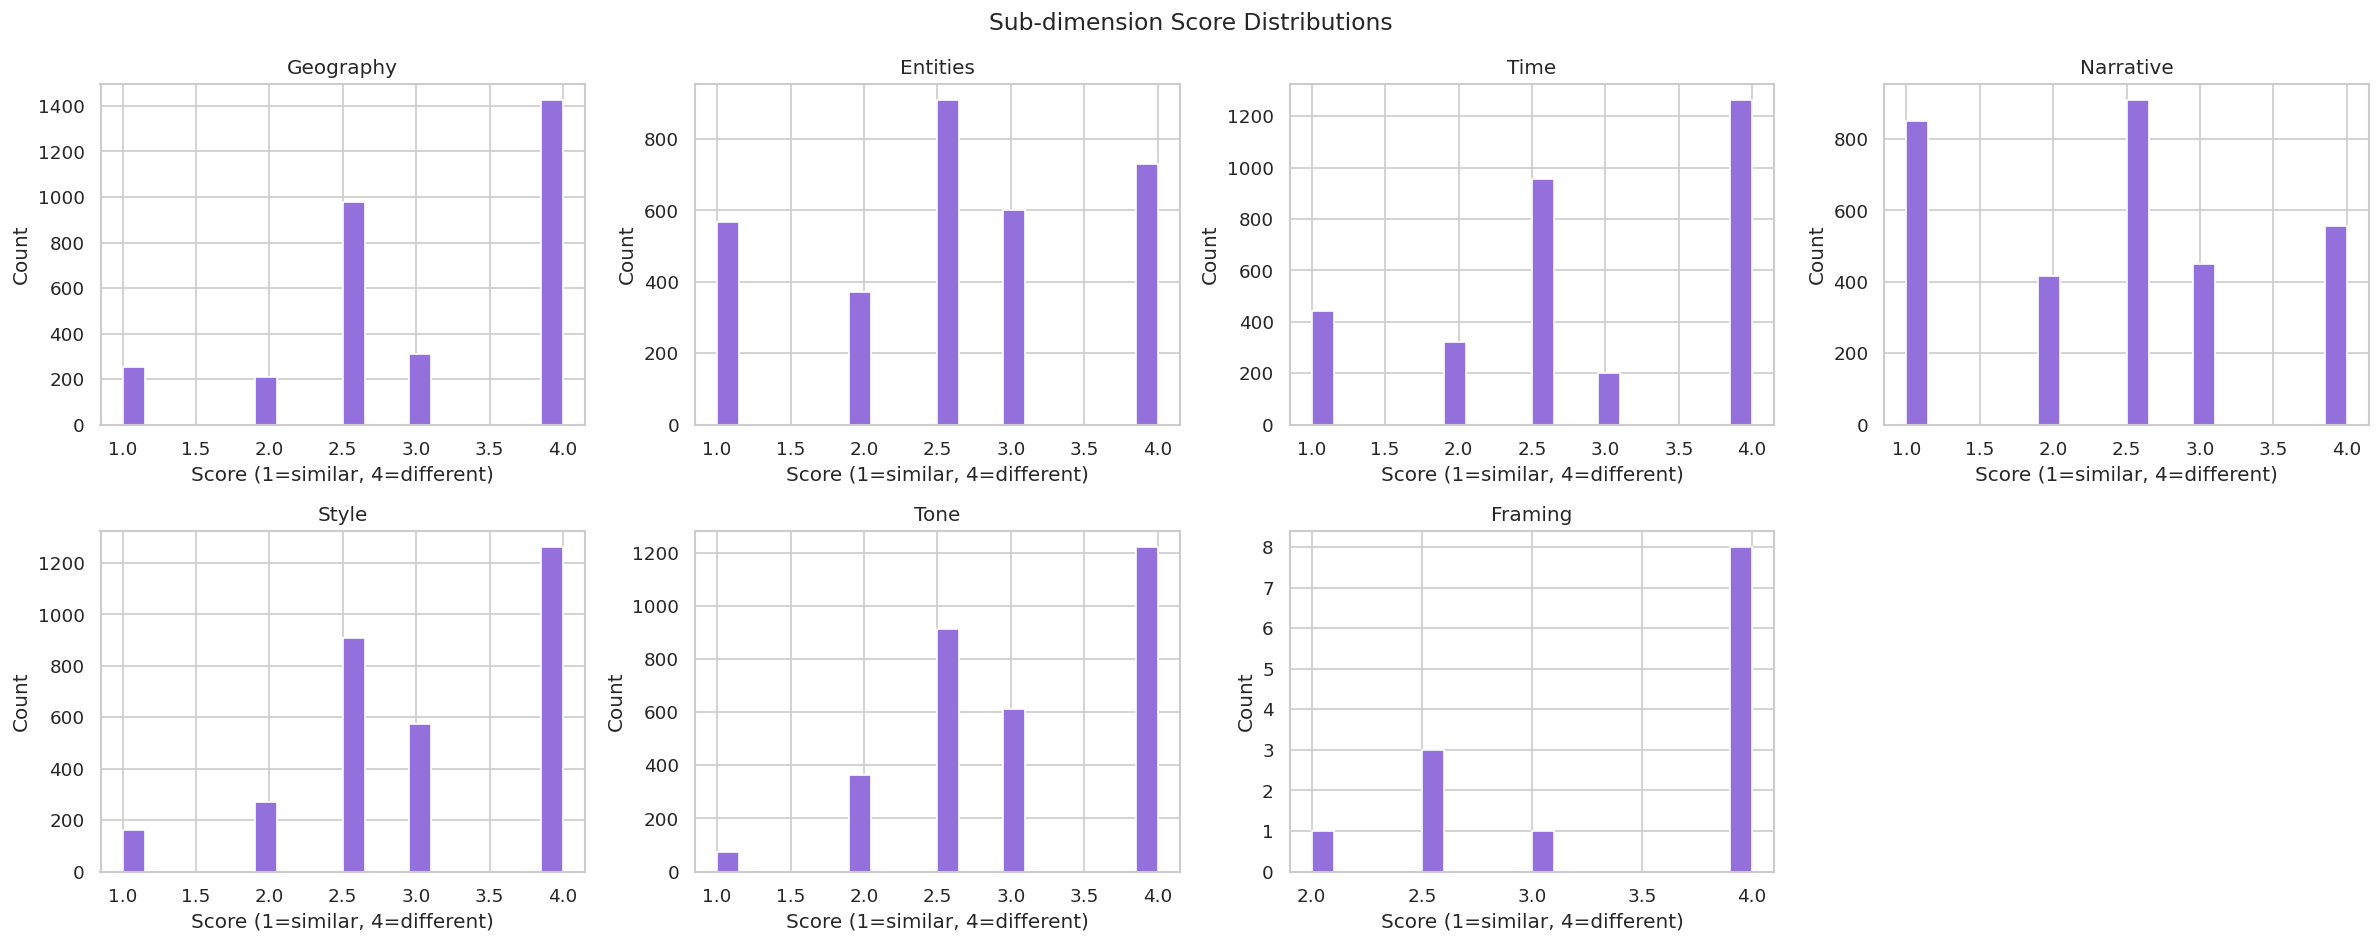

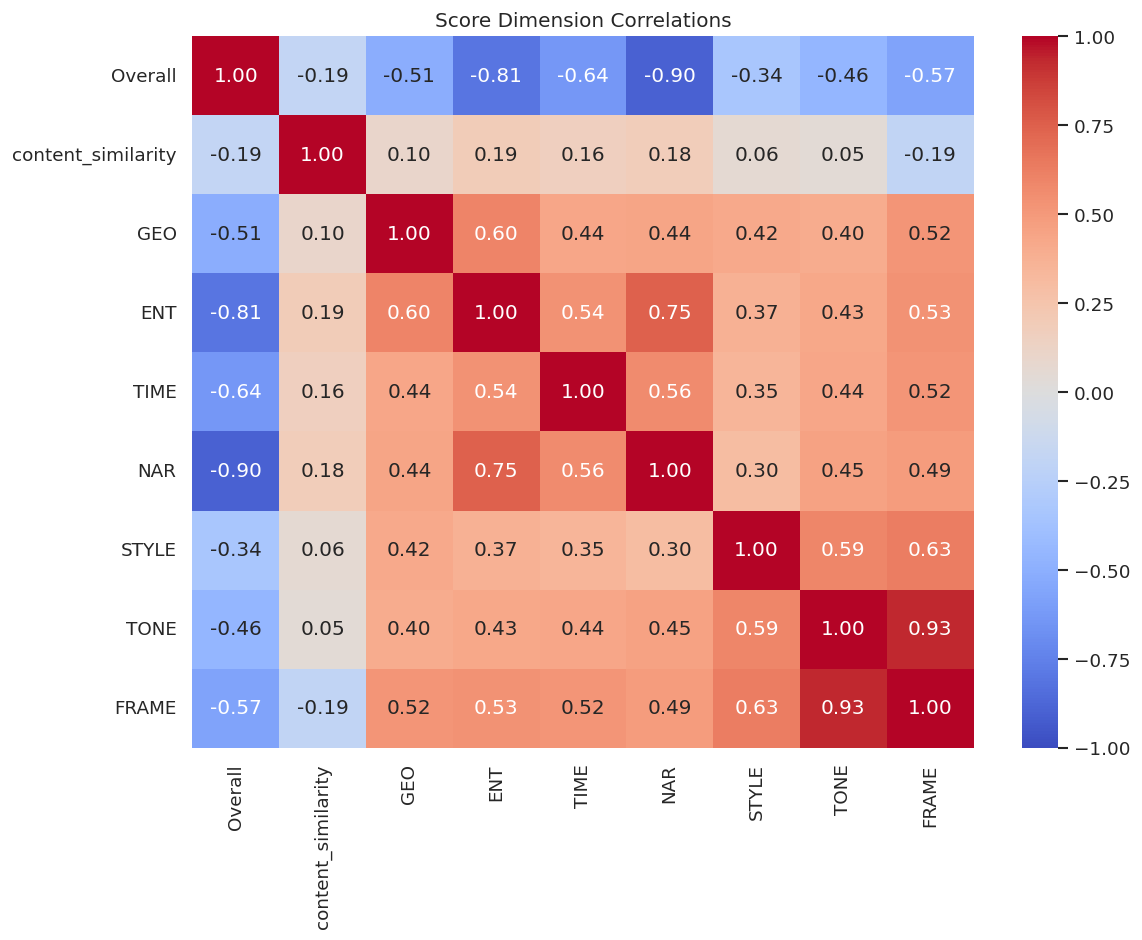

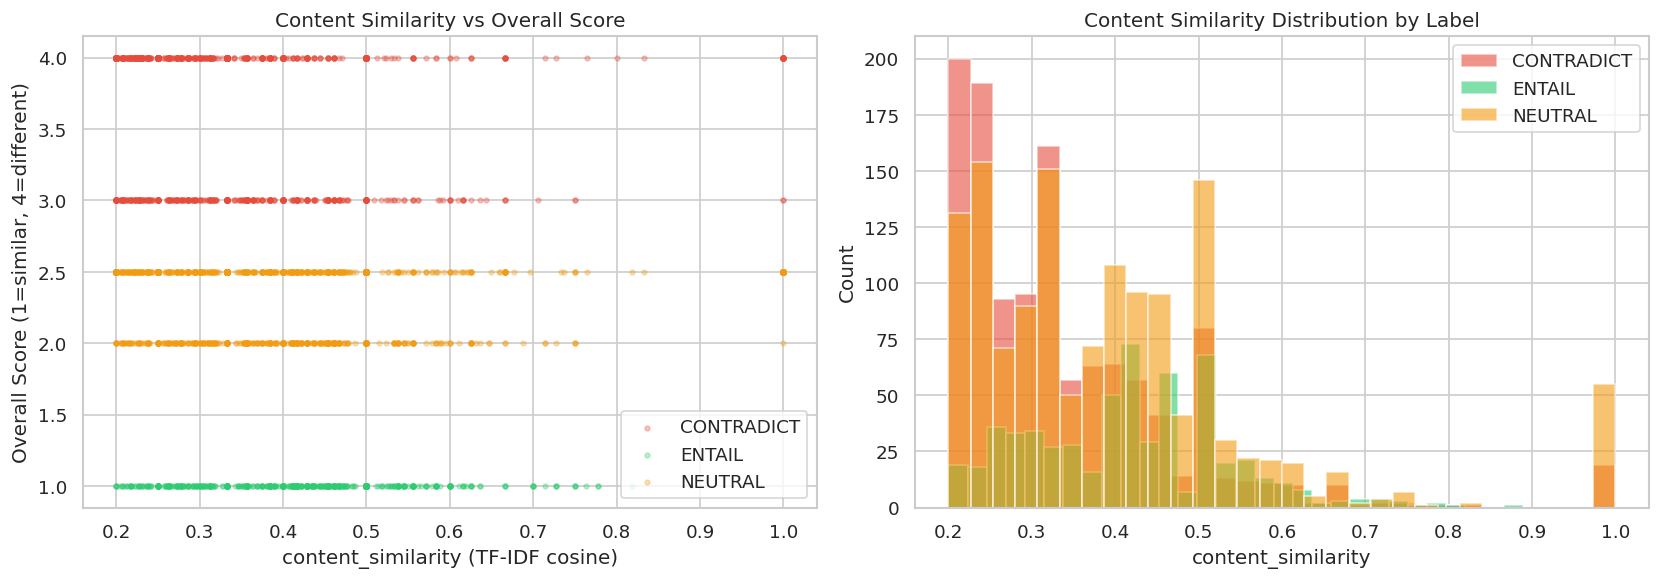

Pearson r (content_similarity vs Overall): -0.185
  → negative means higher TF-IDF similarity = lower Overall score (more similar articles)

content_similarity stats:
count    3181.000
mean        0.382
std         0.153
min         0.200
25%         0.263
50%         0.357
75%         0.462
max         1.000
Name: content_similarity, dtype: float64


In [8]:
sub_cols = [c for c in ['GEO', 'ENT', 'TIME', 'NAR', 'STYLE', 'TONE', 'FRAME'] if c in df.columns]
label_map = {'GEO':'Geography','ENT':'Entities','TIME':'Time','NAR':'Narrative','STYLE':'Style','TONE':'Tone','FRAME':'Framing'}

if sub_cols:
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    for ax, col in zip(axes.flatten(), sub_cols):
        ax.hist(df[col].dropna(), bins=20, color='mediumpurple', edgecolor='white')
        ax.set_title(label_map.get(col, col))
        ax.set_xlabel('Score (1=similar, 4=different)')
        ax.set_ylabel('Count')
    for ax in axes.flatten()[len(sub_cols):]:
        ax.set_visible(False)
    plt.suptitle('Sub-dimension Score Distributions', fontsize=14)
    plt.tight_layout()
    plt.show()

    # correlation heatmap including content_similarity
    corr_cols = ['Overall'] + sub_cols
    if 'content_similarity' in df.columns:
        corr_cols = ['Overall', 'content_similarity'] + sub_cols
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = df[corr_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_title('Score Dimension Correlations')
    plt.tight_layout()
    plt.show()

# content_similarity vs Overall scatter
if 'content_similarity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_map = {'ENTAIL': '#2ecc71', 'NEUTRAL': '#f39c12', 'CONTRADICT': '#e74c3c'}
    for lbl, grp in df.groupby('label'):
        axes[0].scatter(grp['content_similarity'], grp['Overall'],
                        alpha=0.3, s=8, color=colors_map[lbl], label=lbl)
    axes[0].set_xlabel('content_similarity (TF-IDF cosine)')
    axes[0].set_ylabel('Overall Score (1=similar, 4=different)')
    axes[0].set_title('Content Similarity vs Overall Score')
    axes[0].legend()

    # content_similarity distribution by label
    for lbl, grp in df.groupby('label'):
        axes[1].hist(grp['content_similarity'], bins=30, alpha=0.6,
                     color=colors_map[lbl], label=lbl, edgecolor='white')
    axes[1].set_title('Content Similarity Distribution by Label')
    axes[1].set_xlabel('content_similarity')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    corr_val = df['content_similarity'].corr(df['Overall'])
    print(f'Pearson r (content_similarity vs Overall): {corr_val:.3f}')
    print(f'  → negative means higher TF-IDF similarity = lower Overall score (more similar articles)')
    print(f'\ncontent_similarity stats:\n{df["content_similarity"].describe().round(3)}')

### 4.5 Text Length Analysis

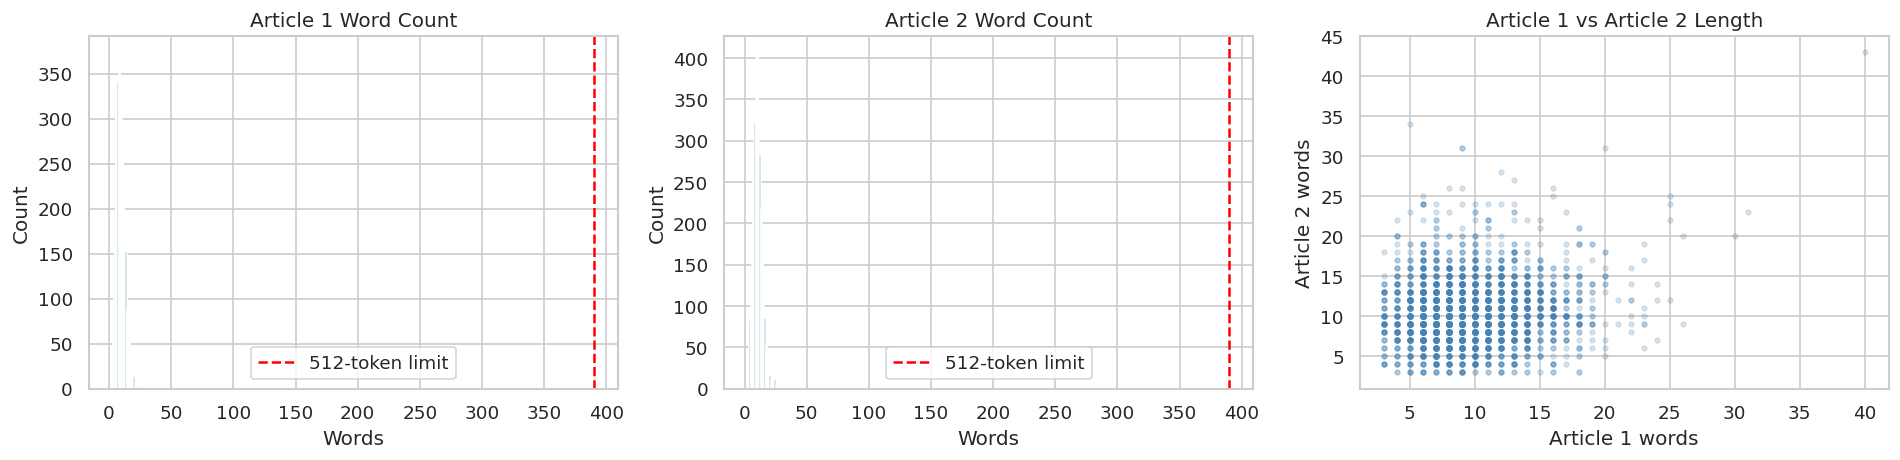

Articles > 390 words (will be truncated): 0 art1, 0 art2
Articles < 10 words: 1712 art1, 1371 art2


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(axes[:2], ['len1','len2'], ['Article 1','Article 2']):
    ax.hist(df[col].clip(upper=400), bins=40, color='teal', edgecolor='white')
    ax.axvline(MAX_WORDS, color='red', linestyle='--', label=f'512-token limit')
    ax.set_title(f'{label} Word Count')
    ax.set_xlabel('Words')
    ax.set_ylabel('Count')
    ax.legend()

axes[2].scatter(df['len1'].clip(upper=400), df['len2'].clip(upper=400),
                alpha=0.2, s=8, color='steelblue')
axes[2].set_title('Article 1 vs Article 2 Length')
axes[2].set_xlabel('Article 1 words')
axes[2].set_ylabel('Article 2 words')

plt.tight_layout()
plt.show()

print(f'Articles > 390 words (will be truncated): {(df["len1"]>390).sum()} art1, {(df["len2"]>390).sum()} art2')
print(f'Articles < 10 words: {(df["len1"]<10).sum()} art1, {(df["len2"]<10).sum()} art2')

### 4.6 Label Distribution by Language Pair

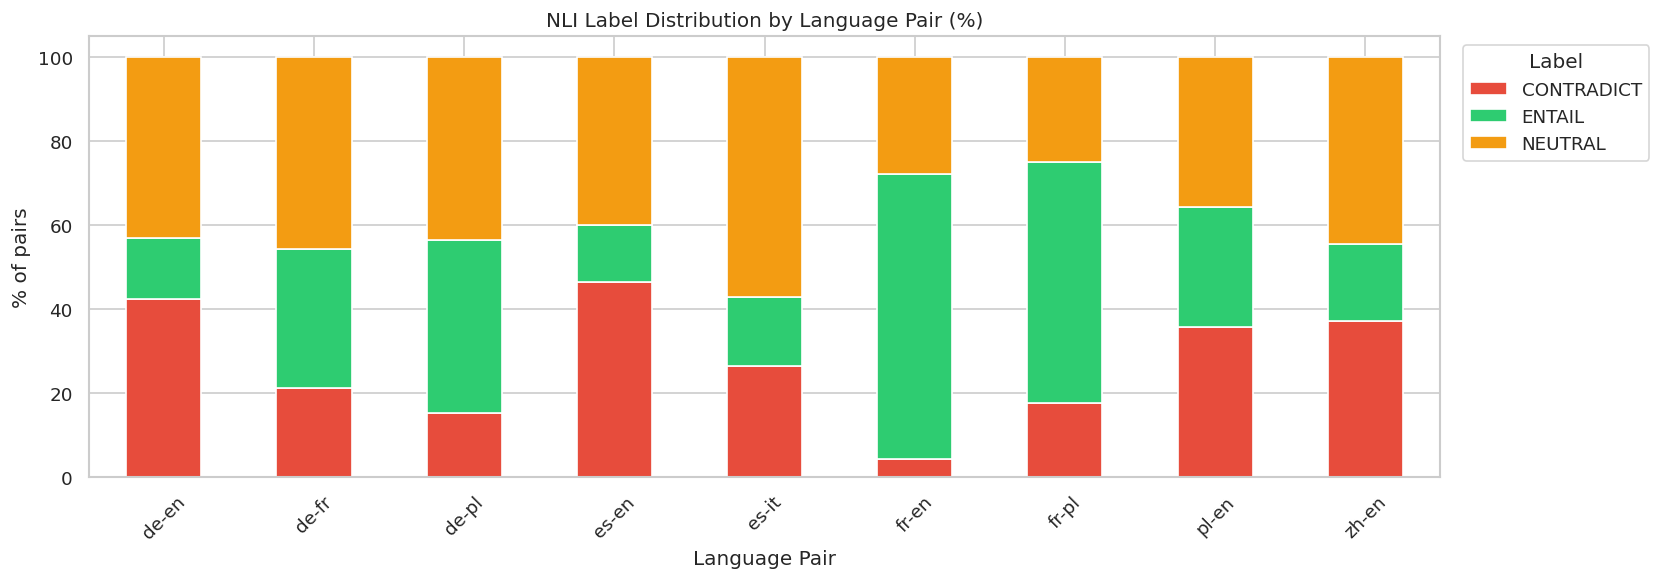

In [10]:
pivot = df.groupby(['lang_pair','label']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(kind='bar', stacked=True, figsize=(14, 5),
               color={'ENTAIL':'#2ecc71','NEUTRAL':'#f39c12','CONTRADICT':'#e74c3c'},
               edgecolor='white')
plt.title('NLI Label Distribution by Language Pair (%)')
plt.xlabel('Language Pair')
plt.ylabel('% of pairs')
plt.xticks(rotation=45)
plt.legend(title='Label', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### 4.7 Sample Pairs per Label

In [11]:
for label in ['ENTAIL', 'NEUTRAL', 'CONTRADICT']:
    row = df[df['label'] == label].sample(1, random_state=42).iloc[0]
    print(f'\n{"="*65}')
    print(f'LABEL: {label}  |  Score: {row["Overall"]}  |  Lang: {row["lang_pair"]}  |  Source: {row["text_source"]}')
    print(f'Text1: {str(row["text1"])[:250]}')
    print(f'Text2: {str(row["text2"])[:250]}')


LABEL: ENTAIL  |  Score: 1.0  |  Lang: de-en  |  Source: title_only
Text1: Trump: &#171;Alles ist gut&#187;, keine Vergeltung, aber dafür weitere Sanktionen
Text2: Donald Trump Gave Televised Address to Nation

LABEL: NEUTRAL  |  Score: 2.0  |  Lang: es-it  |  Source: title_only
Text1: La Serie A suspende tres partidos por Coronavirus
Text2: Coronavirus in Italia, rinviate altre 5 partite del prossimo turno di Lega Pro

LABEL: CONTRADICT  |  Score: 3.0  |  Lang: de-en  |  Source: title_only
Text1: Schwarzer Bloggerin gedroht: Ist Meghan Markles Freundin eine Rassistin?
Text2: Meghan Markle's best friend shares defiant post about 'letting go of the bad'


## 5. Train / Val / Test Split (80 / 10 / 10)

Train: 2544 | Val: 318 | Test: 319


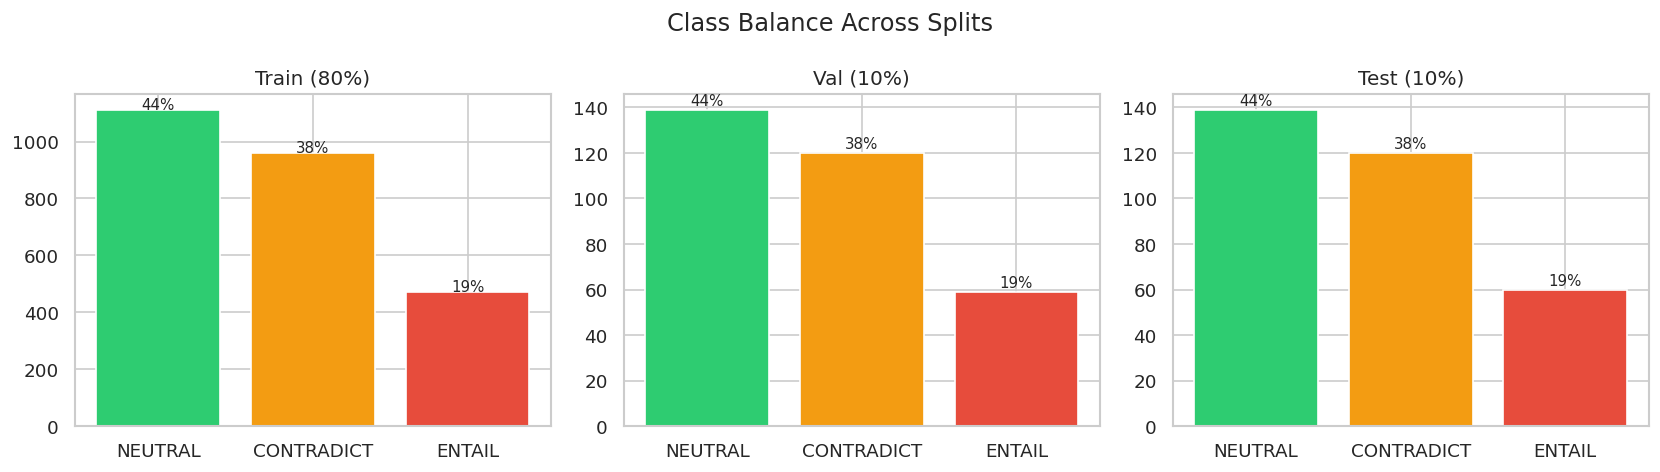

In [12]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, split, title in zip(axes, [train_df, val_df, test_df], ['Train (80%)', 'Val (10%)', 'Test (10%)']):
    c = split['label'].value_counts()
    ax.bar(c.index, c.values, color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
    ax.set_title(title)
    for i, (lbl, v) in enumerate(c.items()):
        ax.text(i, v+2, f'{v/len(split)*100:.0f}%', ha='center', fontsize=9)
plt.suptitle('Class Balance Across Splits')
plt.tight_layout()
plt.show()

## 6. Dataset Class, Metrics & Training Config

In [13]:
class ArticlePairDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.encodings = tokenizer(
            list(df['text1'].fillna('')),
            list(df['text2'].fillna('')),
            truncation=True, padding='max_length',
            max_length=max_length, return_tensors='pt'
        )
        self.labels = torch.tensor(df['label_id'].values, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {**{k: v[idx] for k, v in self.encodings.items()}, 'labels': self.labels[idx]}


def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=-1)
    labels = eval_pred.label_ids
    return {
        'macro_f1':      f1_score(labels, preds, average='macro'),
        'f1_contradict': f1_score(labels, preds, labels=[2], average='macro'),
        'accuracy':      accuracy_score(labels, preds),
        'cohen_kappa':   cohen_kappa_score(labels, preds),
    }


MODELS = {
    'mDeBERTa-v3': 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
    'XLM-RoBERTa': 'cross-encoder/nli-xlm-roberta-base',
    'InfoXLM':     'microsoft/infoxlm-base',
    'mBERT':       'bert-base-multilingual-cased',
}

USE_FP16 = DEVICE == 'cuda'

TRAIN_ARGS = dict(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    fp16=USE_FP16,
    report_to='none',
    logging_steps=50,
)

print('Models:', list(MODELS.keys()))
print(f'fp16: {USE_FP16} | batch: 16 | epochs: 3 | lr: 2e-5')

Models: ['mDeBERTa-v3', 'XLM-RoBERTa', 'InfoXLM', 'mBERT']
fp16: True | batch: 16 | epochs: 3 | lr: 2e-5


## 7. Fine-tune Models — One Cell per Model
Run the **setup cell first**, then run each model cell independently.
Results and metrics print directly in each model's cell.

In [21]:
### 7.0 Training Setup — Run this once before any model cell
import random
from transformers import TrainerCallback

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)

# class weights to handle ENTAIL underrepresentation
label_counts = train_df['label_id'].value_counts().sort_index()
class_weights = len(train_df) / (3 * label_counts.values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f'Class weights → ENTAIL:{class_weights[0]:.3f} | NEUTRAL:{class_weights[1]:.3f} | CONTRADICT:{class_weights[2]:.3f}')

class ProgressCallback(TrainerCallback):
    def __init__(self, model_name): self.model_name = model_name
    def on_epoch_begin(self, args, state, control, **kwargs):
        print(f'\n{"="*60}\n  EPOCH {int(state.epoch)+1}/{int(args.num_train_epochs)} — {self.model_name}\n{"="*60}')
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or not state.is_local_process_zero: return
        step, total = state.global_step, state.max_steps
        parts = [f'step {step}/{total} ({step/total*100:.0f}%)']
        if 'loss' in logs:            parts.append(f'train_loss={logs["loss"]:.4f}')
        if 'eval_loss' in logs:       parts.append(f'val_loss={logs["eval_loss"]:.4f}')
        if 'eval_macro_f1' in logs:   parts.append(f'val_macro_f1={logs["eval_macro_f1"]:.4f}')
        if 'eval_accuracy' in logs:   parts.append(f'val_acc={logs["eval_accuracy"]:.4f}')
        print('  ' + ' | '.join(parts))
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f'  ✓ Epoch {int(state.epoch)} done')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        # cast logits to float32 to handle models that load in fp16
        loss = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)(
            outputs.logits.float(), labels
        )
        return (loss, outputs) if return_outputs else loss

def train_model(model_name, checkpoint, fp16=None):
    use_fp16 = (DEVICE == 'cuda') if fp16 is None else fp16
    print(f'\nLoading {model_name} ({checkpoint})  |  fp16={use_fp16}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True
    )
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

    train_ds = ArticlePairDataset(train_df, tokenizer)
    val_ds   = ArticlePairDataset(val_df,   tokenizer)
    test_ds  = ArticlePairDataset(test_df,  tokenizer)

    args = TrainingArguments(
        output_dir=f'checkpoints/{model_name}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        max_grad_norm=1.0,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        fp16=use_fp16,
        seed=SEED,
        dataloader_num_workers=2,
        logging_steps=50,
        logging_first_step=True,
        report_to='none',
    )
    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2), ProgressCallback(model_name)]
    )
    trainer.train()

    out   = trainer.predict(test_ds)
    preds = np.argmax(out.predictions, axis=-1)
    labs  = test_df['label_id'].values

    print(f'\n{"="*60}\n  {model_name} — TEST SET RESULTS\n{"="*60}')
    print(classification_report(labs, preds, target_names=['ENTAIL','NEUTRAL','CONTRADICT']))
    print(f'  Macro F1:    {f1_score(labs, preds, average="macro"):.4f}')
    print(f'  Cohen Kappa: {cohen_kappa_score(labs, preds):.4f}')

    os.makedirs('predictions', exist_ok=True)
    pred_df = test_df[['pair_id','lang_pair','label','label_id']].copy()
    pred_df['pred_id']    = preds
    pred_df['pred_label'] = [ID2LABEL[p] for p in preds]
    pred_df.to_csv(f'predictions/{model_name}.csv', index=False)
    print(f'  Saved → predictions/{model_name}.csv')

    del model, trainer, train_ds, val_ds, test_ds
    torch.cuda.empty_cache() if DEVICE == 'cuda' else None
    print('  GPU cleared.')

print('Setup complete — run each model cell below.')

Class weights → ENTAIL:1.793 | NEUTRAL:0.763 | CONTRADICT:0.884
Setup complete — run each model cell below.


### 7.1 mBERT — `bert-base-multilingual-cased` (~178M params)

In [15]:
train_model('mBERT', 'bert-base-multilingual-cased')


Loading mBERT (bert-base-multilingual-cased)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


  EPOCH 3/3 — mBERT
  step 350/477 (73%) | train_loss=0.6874
  step 400/477 (84%) | train_loss=0.5937
  step 450/477 (94%) | train_loss=0.5578
  ✓ Epoch 3 done
  step 477/477 (100%) | val_loss=0.8619 | val_macro_f1=0.5796 | val_acc=0.5692


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  step 477/477 (100%)



  mBERT — TEST SET RESULTS
              precision    recall  f1-score   support

      ENTAIL       0.51      0.68      0.58        60
     NEUTRAL       0.67      0.42      0.52       139
  CONTRADICT       0.63      0.80      0.71       120

    accuracy                           0.61       319
   macro avg       0.60      0.63      0.60       319
weighted avg       0.63      0.61      0.60       319

  Macro F1:    0.6010
  Cohen Kappa: 0.4070
  Saved → predictions/mBERT.csv
  GPU cleared.


### 7.2 XLM-RoBERTa — `cross-encoder/nli-xlm-roberta-base` (~270M params)

In [17]:
train_model('XLM-RoBERTa', 'xlm-roberta-base')


Loading XLM-RoBERTa (xlm-roberta-base)


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


  EPOCH 3/3 — XLM-RoBERTa
  step 350/477 (73%) | train_loss=0.8953
  step 400/477 (84%) | train_loss=0.8814
  step 450/477 (94%) | train_loss=0.8319
  ✓ Epoch 3 done
  step 477/477 (100%) | val_loss=0.8438 | val_macro_f1=0.5691 | val_acc=0.5755


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  step 477/477 (100%)



  XLM-RoBERTa — TEST SET RESULTS
              precision    recall  f1-score   support

      ENTAIL       0.44      0.68      0.53        60
     NEUTRAL       0.62      0.25      0.36       139
  CONTRADICT       0.56      0.78      0.65       120

    accuracy                           0.53       319
   macro avg       0.54      0.57      0.51       319
weighted avg       0.56      0.53      0.50       319

  Macro F1:    0.5140
  Cohen Kappa: 0.3016
  Saved → predictions/XLM-RoBERTa.csv
  GPU cleared.


### 7.3 InfoXLM — `microsoft/infoxlm-base` (~270M params)

In [22]:
train_model('InfoXLM', 'microsoft/infoxlm-base', fp16=False)


Loading InfoXLM (microsoft/infoxlm-base)  |  fp16=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: microsoft/infoxlm-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 278,045,955


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...


  EPOCH 3/3 — InfoXLM
  step 350/477 (73%) | train_loss=0.0000
  step 400/477 (84%) | train_loss=0.0000
  step 450/477 (94%) | train_loss=0.0000
  ✓ Epoch 3 done
  step 477/477 (100%) | val_loss=nan | val_macro_f1=0.1043 | val_acc=0.1855


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  step 477/477 (100%)



  InfoXLM — TEST SET RESULTS
              precision    recall  f1-score   support

      ENTAIL       0.19      1.00      0.32        60
     NEUTRAL       0.00      0.00      0.00       139
  CONTRADICT       0.00      0.00      0.00       120

    accuracy                           0.19       319
   macro avg       0.06      0.33      0.11       319
weighted avg       0.04      0.19      0.06       319

  Macro F1:    0.1055
  Cohen Kappa: 0.0000
  Saved → predictions/InfoXLM.csv
  GPU cleared.


### 7.4 mDeBERTa-v3 — `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli` (~279M params)

In [24]:
train_model('mDeBERTa-v3', 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli', fp16=False)


Loading mDeBERTa-v3 (MoritzLaurer/mDeBERTa-v3-base-mnli-xnli)  |  fp16=False


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters: 278,811,651


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...


  EPOCH 3/3 — mDeBERTa-v3
  step 350/477 (73%) | train_loss=0.0000
  step 400/477 (84%) | train_loss=0.0000
  step 450/477 (94%) | train_loss=0.0000
  ✓ Epoch 3 done
  step 477/477 (100%) | val_loss=nan | val_macro_f1=0.1043 | val_acc=0.1855


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

  step 477/477 (100%)



  mDeBERTa-v3 — TEST SET RESULTS
              precision    recall  f1-score   support

      ENTAIL       0.19      1.00      0.32        60
     NEUTRAL       0.00      0.00      0.00       139
  CONTRADICT       0.00      0.00      0.00       120

    accuracy                           0.19       319
   macro avg       0.06      0.33      0.11       319
weighted avg       0.04      0.19      0.06       319

  Macro F1:    0.1055
  Cohen Kappa: 0.0000
  Saved → predictions/mDeBERTa-v3.csv
  GPU cleared.


## 8. (Optional) Reload Saved Predictions Without Retraining
Run this cell instead of Cell 7 if you already have prediction CSVs.

In [26]:
results = {}
for model_name in ['mDeBERTa-v3', 'XLM-RoBERTa', 'InfoXLM', 'mBERT']:
    path = f'predictions/{model_name}.csv'
    if not os.path.exists(path):
        print(f'  {model_name}: not found, skipping')
        continue
    pred_df = pd.read_csv(path)
    preds  = pred_df['pred_id'].values
    labels = pred_df['label_id'].values
    results[model_name] = {
        'macro_f1':      f1_score(labels, preds, average='macro'),
        'f1_contradict': f1_score(labels, preds, labels=[2], average='macro'),
        'accuracy':      accuracy_score(labels, preds),
        'cohen_kappa':   cohen_kappa_score(labels, preds),
        'preds':         preds.tolist(),
        'report':        classification_report(labels, preds, target_names=list(LABEL2ID.keys()))
    }
    print(f'  Loaded {model_name}')
print(f'\nLoaded {len(results)} models')

  Loaded mDeBERTa-v3
  Loaded XLM-RoBERTa
  Loaded InfoXLM
  Loaded mBERT

Loaded 4 models


## 9. Model Comparison

=== Final Model Comparison (Test Set) ===
             macro_f1  f1_contradict  accuracy  cohen_kappa
mDeBERTa-v3    0.1055         0.0000    0.1881       0.0000
XLM-RoBERTa    0.5140         0.6505    0.5329       0.3016
InfoXLM        0.1055         0.0000    0.1881       0.0000
mBERT          0.6010         0.7059    0.6113       0.4070


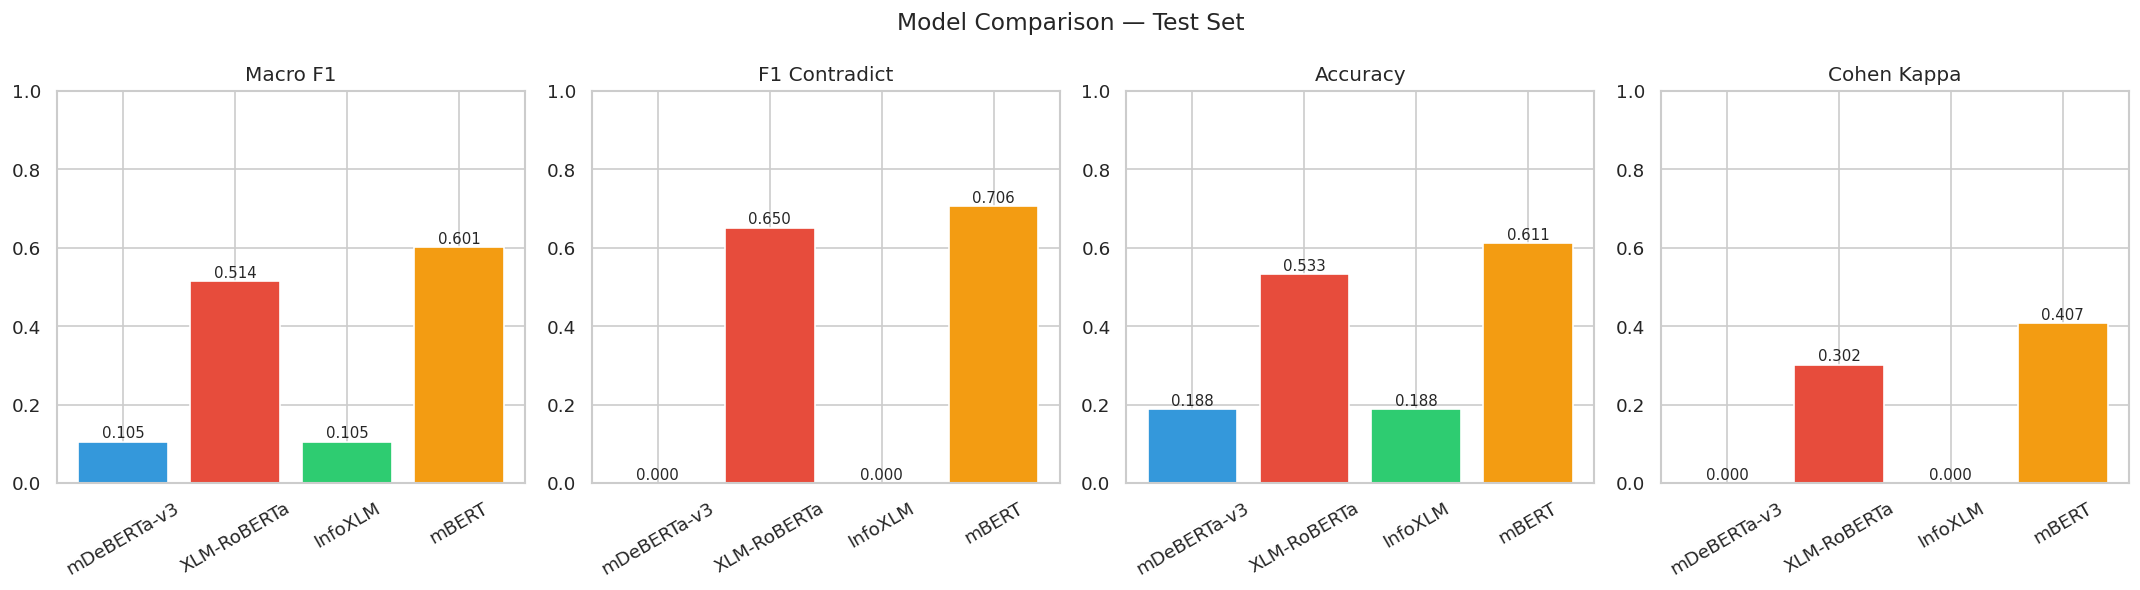

Saved model_comparison.csv


In [27]:
metrics = ['macro_f1', 'f1_contradict', 'accuracy', 'cohen_kappa']
summary = pd.DataFrame(
    {m: {k: results[m][k] for k in metrics} for m in results}
).T.round(4)

print('=== Final Model Comparison (Test Set) ===')
print(summary.to_string())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for ax, metric in zip(axes, metrics):
    vals = summary[metric]
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)], edgecolor='white')
    ax.set_title(metric.replace('_',' ').title())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Model Comparison — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

summary.to_csv('model_comparison.csv')
print('Saved model_comparison.csv')

## 10. Per Language-Pair Breakdown (Best Model)

Best model: mBERT


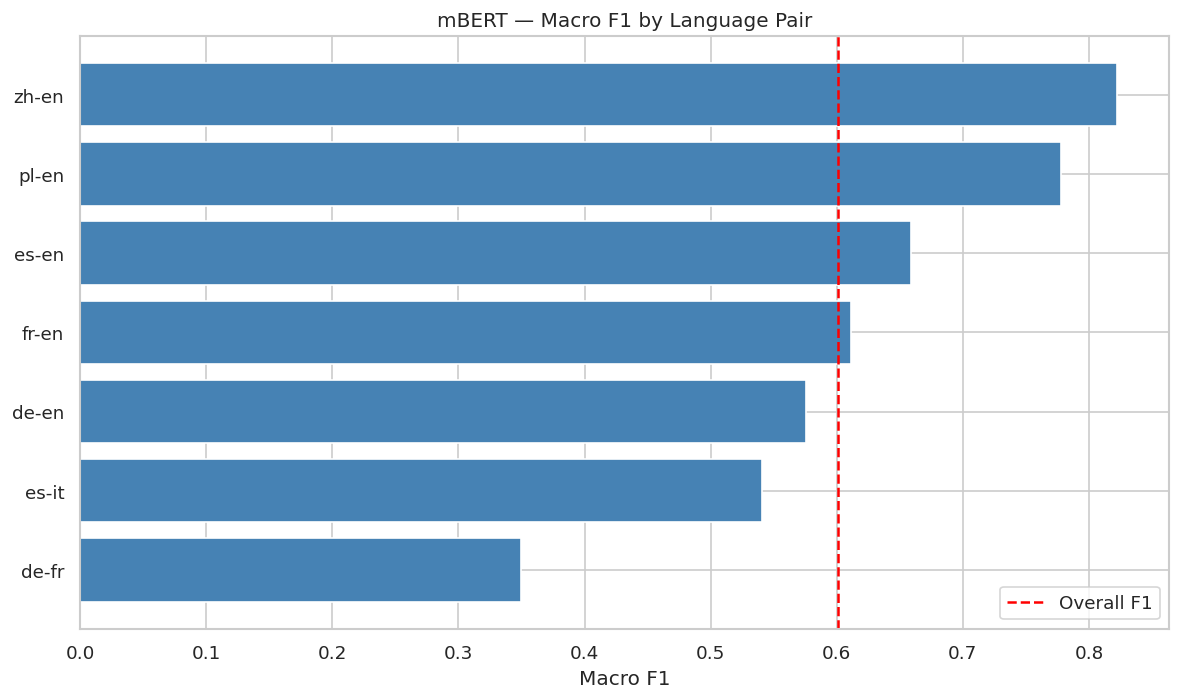

lang_pair   n  macro_f1  accuracy
    de-fr  24  0.349206  0.333333
    es-it  39  0.540741  0.589744
    de-en 142  0.575564  0.598592
    fr-en   8  0.611111  0.750000
    es-en  82  0.658518  0.670732
    pl-en  12  0.777778  0.833333
    zh-en   5  0.822222  0.800000


In [28]:
best_model = summary['macro_f1'].idxmax()
print(f'Best model: {best_model}')

pred_df = pd.read_csv(f'predictions/{best_model}.csv')

lang_results = []
for lang, grp in pred_df.groupby('lang_pair'):
    if len(grp) < 5: continue
    lang_results.append({
        'lang_pair': lang,
        'n': len(grp),
        'macro_f1': f1_score(grp['label_id'], grp['pred_id'], average='macro', zero_division=0),
        'accuracy': accuracy_score(grp['label_id'], grp['pred_id'])
    })

lang_df = pd.DataFrame(lang_results).sort_values('macro_f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lang_df['lang_pair'], lang_df['macro_f1'], color='steelblue', edgecolor='white')
ax.axvline(summary.loc[best_model,'macro_f1'], color='red', linestyle='--', label='Overall F1')
ax.set_title(f'{best_model} — Macro F1 by Language Pair')
ax.set_xlabel('Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

print(lang_df.to_string(index=False))

## 11. Novel Output — Media Bias Matrix
For each outlet pair, what fraction of their article pairs were classified as CONTRADICT?

In [29]:
from urllib.parse import urlparse

OUTLETS = {
    'bbc.com': 'BBC', 'bbc.co.uk': 'BBC',
    'rt.com': 'RT',
    'cnn.com': 'CNN',
    'xinhuanet.com': 'Xinhua',
    'aljazeera.com': 'Al Jazeera',
    'foxnews.com': 'Fox News',
}

print('Upload input.csv to generate the Media Bias Matrix.')
print('Run the next cell after uploading.')

Upload input.csv to generate the Media Bias Matrix.
Run the next cell after uploading.


Saving input.csv to input.csv
Pairs with known outlets: 0


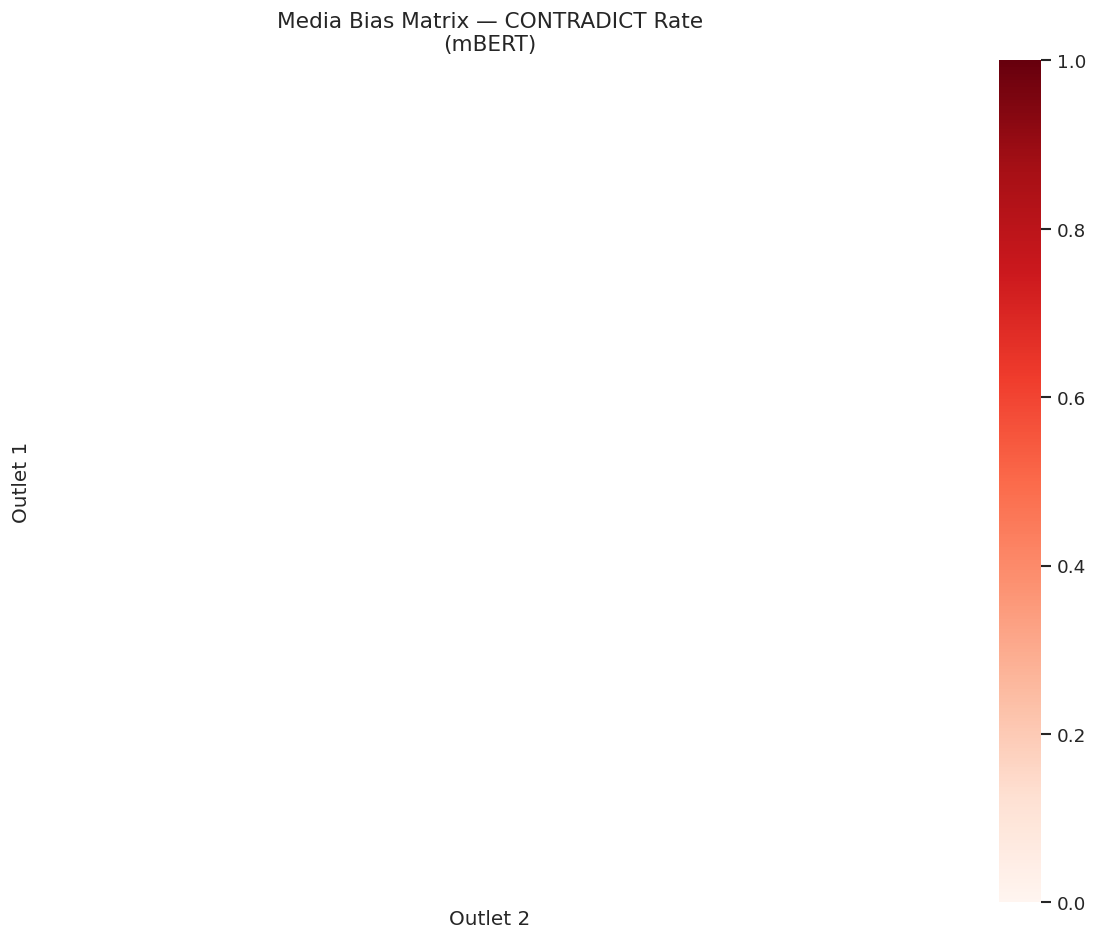

In [30]:
uploaded2 = files.upload()  # upload input.csv when prompted

orig_urls = pd.read_csv('input.csv')[['pair_id','link1','link2']]

def get_outlet(url):
    try:
        domain = urlparse(str(url)).netloc.replace('www.','')
        for key, name in OUTLETS.items():
            if key in domain: return name
    except: pass
    return None

orig_urls['outlet1'] = orig_urls['link1'].apply(get_outlet)
orig_urls['outlet2'] = orig_urls['link2'].apply(get_outlet)

pred_df = pd.read_csv(f'predictions/{best_model}.csv')
bias_df = pred_df.merge(orig_urls, on='pair_id', how='inner')
bias_df = bias_df.dropna(subset=['outlet1','outlet2'])
bias_df['contradict'] = (bias_df['pred_label'] == 'CONTRADICT').astype(int)

print(f'Pairs with known outlets: {len(bias_df)}')

matrix = bias_df.groupby(['outlet1','outlet2'])['contradict'].mean().unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Reds', ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title(f'Media Bias Matrix — CONTRADICT Rate\n({best_model})', fontsize=13)
ax.set_xlabel('Outlet 2')
ax.set_ylabel('Outlet 1')
plt.tight_layout()
plt.show()